In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Qiskit primitives
from qiskit.primitives import StatevectorEstimator

# Algorithms
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

# Ansatz
from qiskit.circuit.library import n_local

# Qiskit Nature
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock

# --- Setup ---
mapper = JordanWignerMapper()
estimator = StatevectorEstimator()
from qiskit_algorithms.optimizers import SLSQP
optimizer = SLSQP(maxiter=300)
# optimizer = COBYLA(maxiter=100)

distances_h2 = np.linspace(0.4, 1.5, 30)
energies_h2 = []

initial_point = None

for d in distances_h2:
    # --- Molecule ---
    mol = MoleculeInfo(
        symbols=["H", "H"],
        coords=[(0.0, 0.0, -d/2), (0.0, 0.0, d/2)],
        multiplicity=1,
        charge=0,
    )

    # --- Driver ---
    driver = PySCFDriver.from_molecule(molecule=mol, basis="sto3g")
    prob = driver.run()

    # --- Freeze core ---
    # prob = FreezeCoreTransformer(freeze_core=True).transform(prob)

    # --- Active space ---
    prob = ActiveSpaceTransformer(
        num_electrons=2,
        num_spatial_orbitals=2
    ).transform(prob)

    # --- Hamiltonian ---
    ham = prob.hamiltonian.second_q_op()
    qubit_op = mapper.map(ham)

    # --- Hartree-Fock initial state ---
    hf = HartreeFock(
        num_spatial_orbitals=prob.num_spatial_orbitals,
        num_particles=prob.num_particles,
        qubit_mapper=mapper,
    )

    # --- Hardware-efficient ansatz ---
    he_ansatz = n_local(
        num_qubits=qubit_op.num_qubits,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cx",
        entanglement="full",
        reps=3   # optimal range
    )

    # --- Combine HF + ansatz ---
    ansatz = hf.compose(he_ansatz)

    # --- VQE ---
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )

    # Warm start
    if initial_point is not None:
        vqe.initial_point = initial_point

    result = vqe.compute_minimum_eigenvalue(qubit_op)
    initial_point = result.optimal_point

    # --- Energy ---
    total_energy = prob.interpret(result).total_energies[0]
    energies_h2.append(total_energy)


In [19]:

# # --- Plot ---
# plt.plot(distances_h2, energies_h2, 'o-')
# plt.xlabel("Internuclear distance (Å)")
# plt.ylabel("Ground state energy (Ha)")
# plt.grid()
# plt.show()

# # --- Equilibrium ---
# min_energy = min(energies_h2)
# min_index = energies_h2.index(min_energy)
# equilibrium_distance = distances_h2[min_index]

# print(f"Minimum ground state energy: {min_energy:.8f} Ha")
# print(f"Equilibrium bond distance: {equilibrium_distance:.4f} Å")

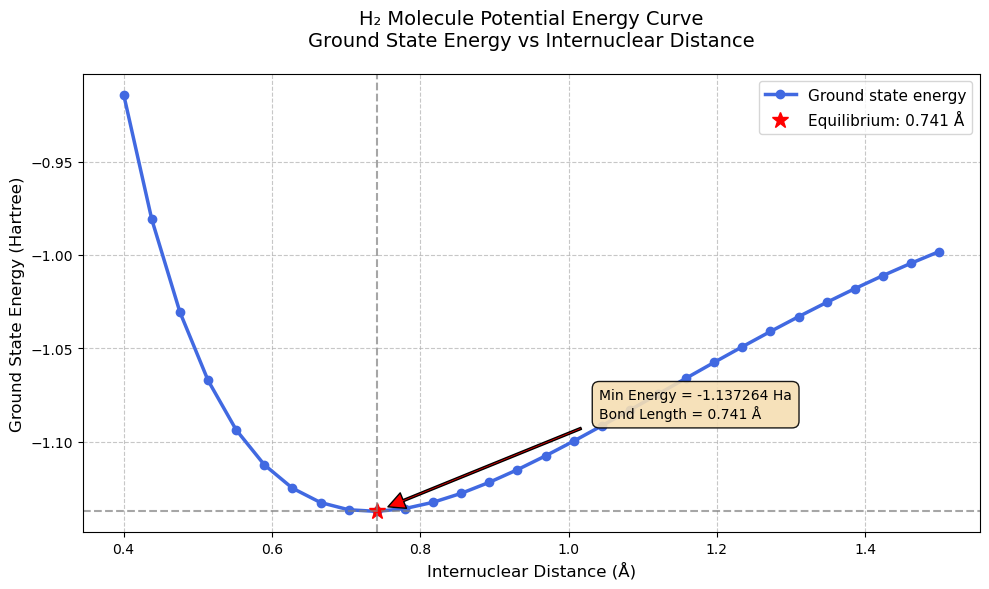

Minimum ground state energy: -1.13726448 Ha
Equilibrium bond distance: 0.7414 Å


In [20]:

plt.figure(figsize=(10, 6))

# Main plot with improved styling
plt.plot(distances_h2, energies_h2, 'o-', 
         color='royalblue', 
         markersize=6, 
         linewidth=2.5, 
         label='Ground state energy')

# Find minimum
min_energy = min(energies_h2)
min_index = energies_h2.index(min_energy)
equilibrium_distance = distances_h2[min_index]

# Highlight the equilibrium point
plt.plot(equilibrium_distance, min_energy, 'r*', 
         markersize=12, 
         label=f'Equilibrium: {equilibrium_distance:.3f} Å')

# Add vertical and horizontal lines at equilibrium
plt.axvline(x=equilibrium_distance, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=min_energy, color='gray', linestyle='--', alpha=0.7)

# Annotations
plt.annotate(f'Min Energy = {min_energy:.6f} Ha\nBond Length = {equilibrium_distance:.3f} Å',
             xy=(equilibrium_distance, min_energy),
             xytext=(equilibrium_distance + 0.3, min_energy + 0.05),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5),
             bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.9))

# Labels and title
plt.xlabel("Internuclear Distance (Å)", fontsize=12)
plt.ylabel("Ground State Energy (Hartree)", fontsize=12)
plt.title("H₂ Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

# Nice touches
plt.tight_layout()
plt.show()

# Print results
print(f"Minimum ground state energy: {min_energy:.8f} Ha")
print(f"Equilibrium bond distance: {equilibrium_distance:.4f} Å")


In [21]:

HARTREE_TO_EV = 27.21138602   # precise conversion factor

# Convert energies to eV
energies_ev = [e * HARTREE_TO_EV for e in energies_h2]

min_energy_ha = min(energies_h2)
min_index = energies_h2.index(min_energy_ha)
equilibrium_distance = distances_h2[min_index]
min_energy_ev = min_energy_ha * HARTREE_TO_EV

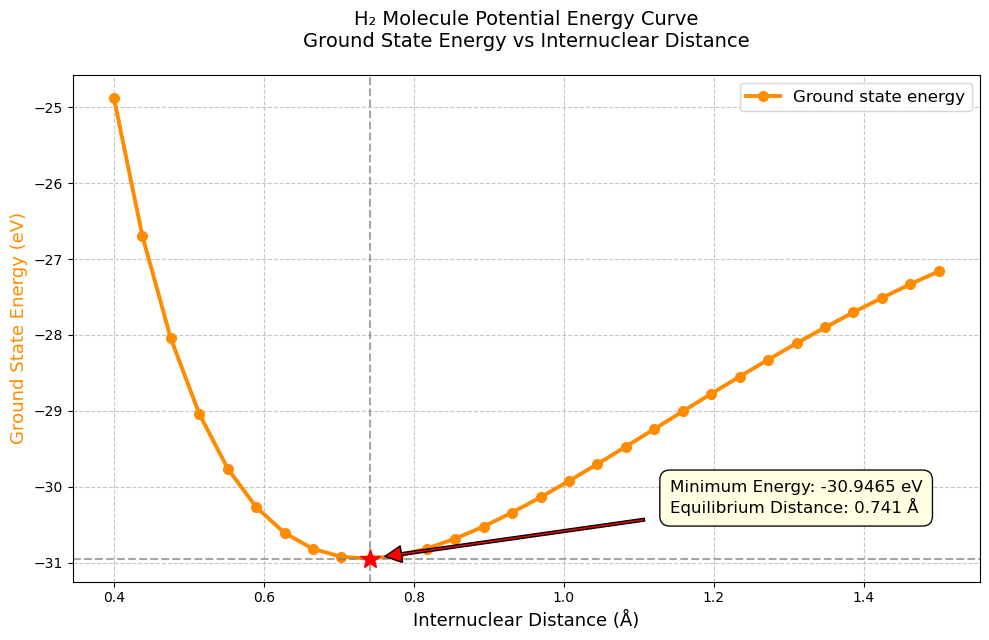

Minimum ground state energy: -30.94654 eV
Equilibrium bond distance:   0.7414 Å


In [22]:


# ====================== PLOTTING ======================
plt.figure(figsize=(10, 6.5))

plt.plot(distances_h2, energies_ev, 'o-', 
         color='darkorange', 
         markersize=7, 
         linewidth=2.8, 
         label='Ground state energy')

# Highlight minimum
plt.plot(equilibrium_distance, min_energy_ev, 'r*', 
         markersize=15, zorder=5)

# Reference lines
plt.axvline(x=equilibrium_distance, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=min_energy_ev, color='gray', linestyle='--', alpha=0.7)

# Annotation
plt.annotate(f'Minimum Energy: {min_energy_ev:.4f} eV\n'
             f'Equilibrium Distance: {equilibrium_distance:.3f} Å',
             xy=(equilibrium_distance, min_energy_ev),
             xytext=(equilibrium_distance + 0.4, min_energy_ev + 0.6),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow", alpha=0.95),
             fontsize=12)

# Labels and Title
plt.xlabel("Internuclear Distance (Å)", fontsize=13)
plt.ylabel("Ground State Energy (eV)", fontsize=13, color='darkorange')

plt.title("H₂ Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Results
print(f"Minimum ground state energy: {min_energy_ev:.5f} eV")
print(f"Equilibrium bond distance:   {equilibrium_distance:.4f} Å")

In [23]:
# Ideal / Reference values
EXACT_ENERGY_EV = -31.96          # Best theoretical non-relativistic
EXACT_DISTANCE = 0.7414           # Experimental
eq_distance = distances_h2[min_index]

# ====================== RESULTS ======================
print("=== RESULTS ===")
print(f"Your Minimum Energy     : {min_energy_ev:.5f} eV")
print(f"Your Equilibrium Distance: {eq_distance:.4f} Å")
print(f"Exact Theoretical Energy : {EXACT_ENERGY_EV:.5f} eV")
print(f"Experimental Bond Length : {EXACT_DISTANCE:.4f} Å")


=== RESULTS ===
Your Minimum Energy     : -30.94654 eV
Your Equilibrium Distance: 0.7414 Å
Exact Theoretical Energy : -31.96000 eV
Experimental Bond Length : 0.7414 Å
